# Phase 2 — train and visualize the adaptation module φ

Trains φ on top of the saved Phase 1 checkpoint, with videos rendered:
1. **Before** training (random-init φ — usually flailing).
2. **Periodically** during training (every `RENDER_EVERY` iters).
3. **After** training (deployed condition: π conditioned on ẑ from φ).
4. **Four-condition comparison** at the end: π(ẑ=φ), π(z=μ), π(0), π(z_random).

Sister files:
* `phase2/train_phi.ipynb` — milestone test harness (M5–M8 assertions).
* `phase2/test_phase2.py` — quick numeric reward-parity test.
* `phase2/PHASE2_EXPLAINER.md` — what this is doing and why.

In [1]:
# Imports + env vars
%env MUJOCO_GL=egl
import os, sys, time, datetime
from pathlib import Path

import jax
import jax.numpy as jp
import numpy as np
import optax
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
from absl import logging
import warnings

from brax.io import model
from brax.training.acme import running_statistics
from brax.training.agents.ppo import networks as ppo_networks
import flax.linen as linen
import functools
from mujoco_playground import registry, wrapper

import twmr  # registers TWMRLegFlat and TWMRLegTerr
from twmr.networks import (
    STUDENT_OBS_SIZE, PRIV_OBS_SIZE, ENV_LATENT_SIZE,
    EnvFactorEncoder, TeacherPolicyNetwork,
)
from twmr.adaptation import HISTORY_LEN, ACTION_SIZE, PER_STEP_FEAT, AdaptationModule

# Phase 2 helpers (live in sandbox/phase2/)
sys.path.insert(0, str(Path("phase2").resolve()))
from rollout_utils import init_history, update_history, extract_frame

# ffmpeg from the project's pixi env (matches phase1_run.ipynb)
media.set_ffmpeg("/home/imeg2025/Transformable-Leg-Wheel-Robot/.pixi/envs/default/bin/ffmpeg")

logging.set_verbosity(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)
print("jax:", jax.__version__, " | device:", jax.default_backend())


env: MUJOCO_GL=egl
jax: 0.6.2  | device: gpu


## Preset

Set `PRESET = "FAST"` for ~5 min iteration runs (reaches reward parity but φ is less polished), or `"FULL"` for the production 1500-iter run (~34 min, matches `test_phase2.py` quality).

In [2]:
PRESETS = {
    "FAST": dict(
        B_ROLLOUT       = 256,
        T_ROLLOUT       = 75,    # drop first HISTORY_LEN ⇒ 50 useful timesteps/env
        NUM_ITERS       = 250,
        NUM_MINIBATCHES = 4,
        LR              = 1e-3,
        RENDER_EVERY    = 100,   # 2 mid-training renders
    ),
    "FULL": dict(
        B_ROLLOUT       = 512,
        T_ROLLOUT       = 75,
        NUM_ITERS       = 1500,
        NUM_MINIBATCHES = 4,
        LR              = 5e-4,
        RENDER_EVERY    = 250,   # 6 mid-training renders
    ),
}
PRESET = "FAST"   # ← change to "FULL" when you're ready for the production run

cfg = PRESETS[PRESET]
print(f"PRESET = {PRESET}")
for k, v in cfg.items():
    print(f"  {k:<16s} = {v}")


PRESET = FAST
  B_ROLLOUT        = 256
  T_ROLLOUT        = 75
  NUM_ITERS        = 250
  NUM_MINIBATCHES  = 4
  LR               = 0.001
  RENDER_EVERY     = 100


## Locate Phase 1 checkpoint

Auto-finds the most recent `f"{ENV_NAME}-*/checkpoints/ppo_final"` under `sandbox/logs/` for the current `ENV_NAME` (set below). Assumes you've already run `phase1_run.ipynb` to completion on the same terrain.

In [3]:
# Switch terrain by changing this string. Registered envs:
#   "TWMRLegFlat" — flat plane (trans_wheel_robo2_2FLAT.xml)
#   "TWMRLegTerr" — heightfield (trans_wheel_robo2_2GEN_TERR.xml)
ENV_NAME = "TWMRLegTerr"

# Teacher glob: tightened to `[0-9]*` (timestamp starts with a digit) so it
# does NOT accidentally match `{ENV_NAME}-PPO-<ts>` baselines, which share the
# env prefix but have a non-digit second component.
candidates = sorted(
    Path("logs").glob(f"{ENV_NAME}-[0-9]*/checkpoints/ppo_final"),
    key=lambda p: p.stat().st_mtime,
)
assert candidates, f"No Phase 1 checkpoint found for {ENV_NAME!r}; run phase1_run.ipynb on this terrain first."
CHECKPOINT_PATH = candidates[-1]
RUN_DIR   = CHECKPOINT_PATH.parent.parent       # sandbox/logs/<ENV_NAME>-<ts>/
CKPT_DIR  = CHECKPOINT_PATH.parent              # sandbox/logs/<ENV_NAME>-<ts>/checkpoints/
VIDEO_DIR = RUN_DIR / "phase2_videos"
VIDEO_DIR.mkdir(exist_ok=True)

# PPO baseline (5th condition): trained by sandbox/train_only_ppo.ipynb. We
# auto-discover the latest `{ENV_NAME}-PPO-*` run.
ppo_candidates = sorted(
    Path("logs").glob(f"{ENV_NAME}-PPO-*/checkpoints/ppo_final"),
    key=lambda p: p.stat().st_mtime,
)
assert ppo_candidates, (
    f"No plain-PPO baseline found for {ENV_NAME!r}; "
    f"run sandbox/train_only_ppo.ipynb on this terrain first."
)
PPO_CHECKPOINT_PATH = ppo_candidates[-1]

print(f"env:            {ENV_NAME}")
print(f"checkpoint:     {CHECKPOINT_PATH}")
print(f"ppo_checkpoint: {PPO_CHECKPOINT_PATH}")
print(f"videos:         {VIDEO_DIR}")


env:            TWMRLegTerr
checkpoint:     logs/TWMRLegTerr-20260528-160033/checkpoints/ppo_final
ppo_checkpoint: logs/TWMRLegTerr-PPO-20260528-152643/checkpoints/ppo_final
videos:         logs/TWMRLegTerr-20260528-160033/phase2_videos


## Build env

Two env instances:
* `env`: vectorized for parallel rollouts; `naconmax` sized for the   largest planned B (512) so MJX never silently drops contacts.
* `_render_env` / `_render_wrapped`: a separate single-env used only   for rendering (mirrors the pattern in `phase1_run.ipynb`).

In [4]:
import functools

# ENV_NAME is defined upstream (cell 5) so the checkpoint glob picks the
# right per-terrain Phase 1 run; we just reuse it here.
EPISODE_LENGTH = 250
MAX_B          = 512                # size naconmax for the worst case
NACONMAX       = 40 * MAX_B        # bumped 25→40 for TERR contact headroom
NJMAX          = 1000

raw_env = registry.load(ENV_NAME, config_overrides={"naconmax": NACONMAX, "njmax": NJMAX})

# Per-env friction (geom_friction[ground,0]) lives at the mjx_model level,
# not in `state.info`. Phase 2 must train under the same physics distribution
# as Phase 1, so wrap with the same randomize fn.
# rng batch size MUST match the B used in env.reset(...), which is
# cfg["B_ROLLOUT"] in this notebook's DAgger loop.
randomize_train = functools.partial(
    twmr.twmr.domain_randomize_model,
    rng=jax.random.split(jax.random.PRNGKey(0), cfg["B_ROLLOUT"]),
)
env = wrapper.wrap_for_brax_training(
    raw_env,
    episode_length=EPISODE_LENGTH,
    action_repeat=1,
    randomization_fn=randomize_train,
)

# Render env stays un-randomized (single-env, neutral physics for comparable
# behavior across rendered checkpoints).
_render_env     = registry.load(ENV_NAME)
_render_wrapped = wrapper.wrap_for_brax_training(_render_env, episode_length=EPISODE_LENGTH, action_repeat=1)

print(f"action_size={raw_env.action_size}  obs_size={raw_env.observation_size}")
assert raw_env.action_size == ACTION_SIZE


Warp 1.12.1 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla V100-SXM2-32GB" (32 GiB, sm_70, mempool enabled)
     "cuda:1"   : "Tesla V100-SXM2-32GB" (32 GiB, sm_70, mempool enabled)
     "cuda:2"   : "Tesla V100-SXM2-32GB" (32 GiB, sm_70, mempool enabled)
     "cuda:3"   : "Tesla V100-SXM2-32GB" (32 GiB, sm_70, mempool enabled)
   CUDA peer access:
     Supported fully (all-directional)
   Kernel cache:
     /home/imeg2025/.cache/warp/1.12.1
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 10.87 ms  (cached)
action_size=8  obs_size=38


## Load Phase 1 checkpoint

`ppo_final` contains `(norm_params, policy_params, value_params)`. We use `norm_params` and `policy_params`; the value network is dropped. μ's params live inside `policy_params["params"]["EnvFactorEncoder_0"]`.

In [5]:
POLICY_HIDDEN = (64, 64, 64)

norm_params, policy_params, _value_params = model.load_params(str(CHECKPOINT_PATH))

policy_module = TeacherPolicyNetwork(
    action_size=2 * raw_env.action_size,           # NormalTanhDistribution param size
    hidden_layer_sizes=POLICY_HIDDEN,
    latent_dim=ENV_LATENT_SIZE,
)
mu_module = EnvFactorEncoder(latent_dim=ENV_LATENT_SIZE)
mu_params = {"params": policy_params["params"]["EnvFactorEncoder_0"]}

def normalize_obs(obs):
    return running_statistics.normalize(obs, norm_params)

def compute_z(obs_norm):
    """True z from μ on the privileged slice of normalized obs."""
    priv = obs_norm[..., STUDENT_OBS_SIZE:STUDENT_OBS_SIZE + PRIV_OBS_SIZE]
    return mu_module.apply(mu_params, priv)

def policy_action_with_z(obs_norm, z):
    """Deployment inference path: π conditioned on an externally supplied z."""
    student = obs_norm[..., :STUDENT_OBS_SIZE]
    logits  = policy_module.apply(
        policy_params, student, z, method=TeacherPolicyNetwork.apply_with_z
    )
    return jp.tanh(logits[..., :ACTION_SIZE])      # deterministic action

print("checkpoint loaded; π + μ + norm_params ready.")


# ── PPO baseline (5th condition) ─────────────────────────────────────────────
# Plain PPO trained on the 29-dim student obs. No encoder, no z. We just need
# a jitted inference closure that maps obs_29 → action_8.
ppo_norm_params, ppo_policy_params, _ = model.load_params(str(PPO_CHECKPOINT_PATH))
ppo_network = ppo_networks.make_ppo_networks(
    observation_size=STUDENT_OBS_SIZE,                 # 29
    action_size=ACTION_SIZE,                            # 8
    preprocess_observations_fn=running_statistics.normalize,
    policy_hidden_layer_sizes=(64, 64, 64),
    value_hidden_layer_sizes=(64, 64, 64),
    activation=linen.tanh,
)
ppo_make_inference = ppo_networks.make_inference_fn(ppo_network)
ppo_infer = jax.jit(
    ppo_make_inference((ppo_norm_params, ppo_policy_params), deterministic=True)
)
print("ppo baseline loaded; ppo_infer ready.")


checkpoint loaded; π + μ + norm_params ready.
ppo baseline loaded; ppo_infer ready.


## Video render helper (inline)

Adapted from `phase1_run.ipynb`'s `render_rollout`. Differences:
* maintains the `(1, 25, 37)` history buffer alongside env state;
* uses `policy_module.apply_with_z` instead of the standard inference fn;
* `latent_mode` selects which latent feeds π — `"phi"` (deployed), `"mu"` (teacher), `"zero"`, or `"random"`.

Camera + scene options copied from Phase 1's renderer.

In [6]:
RENDER_T   = 250
RENDER_FPS = 1.0 / _render_env.dt    # 50 Hz

# Constants for diagnostic plots (mirror those redeclared in Phase 1).
_WHEEL_MAX_SPEED = 8.0
_LEG_CENTER      = 1.19
_LEG_HALF_RANGE  = 2.237
_LEG_MIN, _LEG_MAX = -1.047, 3.427
_WHEEL_QVEL_IDX  = np.array([6, 10, 14, 18])

# A rough order-of-magnitude std(z) — used only for the "random" baseline.
# (The exact value matters very little; this is a sanity-check baseline that
# should perform poorly regardless.)
Z_STD_FALLBACK = jp.ones(ENV_LATENT_SIZE) * 0.7

# Make four jitted rollout functions — one per latent mode. Each compiles
# once on first call and is cached for the rest of the notebook.
def _make_rollout(latent_fn):
    def rollout(rng, phi_params):
        rng, k_reset = jax.random.split(rng)
        state = _render_wrapped.reset(jax.random.split(k_reset, 1))
        buf   = init_history(1, HISTORY_LEN, PER_STEP_FEAT)

        def step_fn(carry, i):
            state, buf, key = carry
            key, sk = jax.random.split(key)
            on  = normalize_obs(state.obs)
            z   = latent_fn(on, buf, sk, phi_params)
            a   = policy_action_with_z(on, z)
            student = on[..., :STUDENT_OBS_SIZE]
            new_buf = update_history(buf, extract_frame(student, a))
            new_state = _render_wrapped.step(state, a)
            return (new_state, new_buf, key), (new_state.data, a)

        _, (traj, acts) = jax.lax.scan(
            step_fn, (state, buf, rng), jp.arange(RENDER_T)
        )
        return traj, acts
    return jax.jit(rollout)

_rollout_phi    = _make_rollout(lambda on, buf, k, p: phi_module.apply(p, buf))
_rollout_mu     = _make_rollout(lambda on, buf, k, p: compute_z(on))
_rollout_zero   = _make_rollout(lambda on, buf, k, p: jp.zeros((1, ENV_LATENT_SIZE)))
_rollout_random = _make_rollout(lambda on, buf, k, p: jax.random.normal(k, (1, ENV_LATENT_SIZE)) * Z_STD_FALLBACK)

_ROLLOUTS = {"phi": _rollout_phi, "mu": _rollout_mu, "zero": _rollout_zero, "random": _rollout_random}

phi_module = AdaptationModule(latent_dim=ENV_LATENT_SIZE)   # used by _rollout_phi above


# ── 5th condition: plain PPO baseline ────────────────────────────────────────
# PPO has its own normalizer (ppo_norm_params) baked into ppo_infer, sees only
# the 29-dim student slice, and does NOT use the history buffer or z. We can't
# reuse `_make_rollout(latent_fn)` because that factory assumes the action
# comes from `policy_action_with_z(on, z)`.
def _make_ppo_rollout():
    def rollout(rng, _unused_phi_params):
        rng, k_reset = jax.random.split(rng)
        state = _render_wrapped.reset(jax.random.split(k_reset, 1))   # state.obs is 38-dim

        def step_fn(carry, _):
            s, key = carry
            key, sk = jax.random.split(key)
            obs29 = s.obs[..., :STUDENT_OBS_SIZE]                    # slice for PPO
            a = jax.vmap(ppo_infer)(obs29, jax.random.split(sk, 1))[0]
            new_state = _render_wrapped.step(s, a)
            return (new_state, key), (new_state.data, a)

        _, (traj, acts) = jax.lax.scan(step_fn, (state, rng), None, length=RENDER_T)
        return traj, acts
    return jax.jit(rollout)

_rollout_ppo = _make_ppo_rollout()
_ROLLOUTS["ppo"] = _rollout_ppo


## Multi-episode averaged-distance eval

The per-video `max_x` printed by `render_phi_rollout` is one trial on the un-randomized render env, so it doesn't reflect test-time variability. This helper runs `N_EVAL_EPISODES` envs in parallel under the same DR distribution as training (a fresh `_eval_env_randomized` wrapping `raw_env` with `domain_randomize_model`) and reports mean ± std of max forward distance. Called alongside the final-φ render and once per condition in the four-condition comparison.

N=50 chosen as a stat-vs-cost balance: SE of the mean ≈ σ/√50 ≈ 0.02 m if individual-trial σ≈0.15 m — tight enough to separate phi/mu/zero/random, while keeping a single eval call to one parallel `lax.scan` (~1–2 s after JIT warmup).

In [7]:
N_EVAL_EPISODES = 50   # SE ≈ σ/√50 ≈ 0.02m; one parallel rollout ~ 1–2 s on GPU.

# Randomized eval env (separate from `env` because B differs from B_ROLLOUT and
# we want a deterministic, eval-only DR sample independent of training rng).
randomize_eval = functools.partial(
    twmr.twmr.domain_randomize_model,
    rng=jax.random.split(jax.random.PRNGKey(2026), N_EVAL_EPISODES),
)
_eval_env_randomized = wrapper.wrap_for_brax_training(
    raw_env,
    episode_length=EPISODE_LENGTH,
    action_repeat=1,
    randomization_fn=randomize_eval,
)

def _make_eval(latent_fn):
    """Factory: one jitted N-env rollout that returns per-env max forward distance.

    Mirrors `_make_rollout` but vectorized over `N_EVAL_EPISODES` randomized envs
    instead of a single render env, and skips frame rendering. Distance convention
    matches `render_phi_rollout`: `qpos[:, 0].max() - qpos[0, 0]` per env.
    """
    def run(rng, phi_params):
        rng, k_reset = jax.random.split(rng)
        state = _eval_env_randomized.reset(jax.random.split(k_reset, N_EVAL_EPISODES))
        buf   = init_history(N_EVAL_EPISODES, HISTORY_LEN, PER_STEP_FEAT)
        x0    = state.data.qpos[:, 0]                       # (N,)

        def step_fn(carry, _):
            state, buf, key = carry
            key, sk = jax.random.split(key)
            on  = normalize_obs(state.obs)
            z   = latent_fn(on, buf, sk, phi_params)
            a   = policy_action_with_z(on, z)
            student = on[..., :STUDENT_OBS_SIZE]
            new_buf = update_history(buf, extract_frame(student, a))
            new_state = _eval_env_randomized.step(state, a)
            return (new_state, new_buf, key), new_state.data.qpos[:, 0]

        _, x_traj = jax.lax.scan(
            step_fn, (state, buf, rng), None, length=EPISODE_LENGTH,
        )                                                   # x_traj: (T, N)
        return x_traj.max(axis=0) - x0                      # (N,)
    return jax.jit(run)

_eval_phi    = _make_eval(lambda on, buf, k, p: phi_module.apply(p, buf))
_eval_mu     = _make_eval(lambda on, buf, k, p: compute_z(on))
_eval_zero   = _make_eval(lambda on, buf, k, p: jp.zeros((N_EVAL_EPISODES, ENV_LATENT_SIZE)))
_eval_random = _make_eval(lambda on, buf, k, p: jax.random.normal(k, (N_EVAL_EPISODES, ENV_LATENT_SIZE)) * Z_STD_FALLBACK)
_EVALS = {"phi": _eval_phi, "mu": _eval_mu, "zero": _eval_zero, "random": _eval_random}

def eval_avg_distance(phi_params, latent_mode="phi", seed=2024):
    """Return (mean_m, std_m, per_episode_array) over N_EVAL_EPISODES randomized rollouts."""
    rng = jax.random.PRNGKey(seed)
    dists = _EVALS[latent_mode](rng, phi_params)
    dists.block_until_ready()
    arr = np.array(dists)
    return float(arr.mean()), float(arr.std()), arr


# ── 5th condition eval: plain PPO baseline on the SAME 50 randomized envs ────
def _make_ppo_eval():
    def run(rng, _unused_phi_params):
        rng, k_reset = jax.random.split(rng)
        state = _eval_env_randomized.reset(jax.random.split(k_reset, N_EVAL_EPISODES))
        x0    = state.data.qpos[:, 0]

        def step_fn(carry, _):
            s, key = carry
            key, sk = jax.random.split(key)
            obs29 = s.obs[..., :STUDENT_OBS_SIZE]                    # slice for PPO
            a = jax.vmap(ppo_infer)(obs29, jax.random.split(sk, N_EVAL_EPISODES))[0]
            new_state = _eval_env_randomized.step(s, a)
            return (new_state, key), new_state.data.qpos[:, 0]

        _, x_traj = jax.lax.scan(step_fn, (state, rng), None, length=EPISODE_LENGTH)
        return x_traj.max(axis=0) - x0
    return jax.jit(run)

_eval_ppo = _make_ppo_eval()
_EVALS["ppo"] = _eval_ppo


In [8]:
def render_phi_rollout(phi_params, label, latent_mode="phi", seed=12345,
                       save=True, show=True, plots=False):
    """Render one deterministic episode and (optionally) display + save mp4.

    label: short string used in filenames and printouts.
    latent_mode: which latent feeds π — see _ROLLOUTS keys.
    plots: if True, also save wheel-velocity / leg-position diagnostic PNGs.
    """
    t0 = time.monotonic()
    rng = jax.random.PRNGKey(seed)
    traj, acts = _ROLLOUTS[latent_mode](rng, phi_params)
    traj.qpos.block_until_ready()

    qpos_np = np.array(traj.qpos[:, 0])
    qvel_np = np.array(traj.qvel[:, 0])
    acts_np = np.array(acts[:, 0])
    ctrl_np = np.array(traj.ctrl[:, 0])

    max_x = float(qpos_np[:, 0].max() - qpos_np[0, 0])
    n_steps = qpos_np.shape[0]

    # ── Render frames ─────────────────────────────────────────────────────
    mj_model = _render_env.mj_model
    renderer = mujoco.Renderer(mj_model, height=480, width=640)
    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(mj_model, cam)
    cam.azimuth, cam.elevation, cam.distance = 135.0, -20.0, 1.5
    chassis_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "chassis")

    scene_opt = mujoco.MjvOption()
    mujoco.mjv_defaultOption(scene_opt)
    scene_opt.flags[mujoco.mjtVisFlag.mjVIS_AUTOCONNECT]  = False
    scene_opt.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = False
    scene_opt.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE]    = False
    scene_opt.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT]  = False
    scene_opt.geomgroup[3] = 0   # hide collision geoms — kills z-fighting flicker

    d = mujoco.MjData(mj_model)
    frames = []
    for i in range(n_steps):
        d.qpos[:] = qpos_np[i]
        d.qvel[:] = qvel_np[i]
        mujoco.mj_forward(mj_model, d)
        cam.lookat[:] = d.xpos[chassis_id]
        renderer.update_scene(d, camera=cam, scene_option=scene_opt)
        frames.append(renderer.render())
    renderer.close()

    out_path = VIDEO_DIR / f"{label}.mp4"
    if save:
        media.write_video(str(out_path), frames, fps=RENDER_FPS)
    if show:
        media.show_video(frames, fps=RENDER_FPS)
    print(f"  [{label}] mode={latent_mode} max_x={max_x:.2f}m  ({time.monotonic()-t0:.1f}s)"
          + (f"  → {out_path}" if save else ""))

    # ── Optional diagnostic plots (off by default to keep cells fast) ─────
    if plots:
        wheel_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:4]
        time_s = np.arange(n_steps) * 0.02
        des_wheel = acts_np[:, :4] * _WHEEL_MAX_SPEED
        act_wheel = qvel_np[:, _WHEEL_QVEL_IDX]
        wheel_torque = ctrl_np[:, :4]

        fig, (axv, axt) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
        for i in range(4):
            axv.plot(time_s, des_wheel[:, i], color=wheel_colors[i], lw=1.0, label=f"w{i} desired")
            axv.plot(time_s, act_wheel[:, i], color=wheel_colors[i], lw=1.0, ls="--", label=f"w{i} actual")
        axv.set_ylabel("wheel vel (rad/s)"); axv.legend(fontsize=6, ncol=2); axv.grid(alpha=0.3)
        for i in range(4):
            axt.plot(time_s, wheel_torque[:, i], color=wheel_colors[i], lw=1.0, label=f"w{i}")
        axt.set_xlabel("time (s)"); axt.set_ylabel("torque (N·m)"); axt.legend(fontsize=7); axt.grid(alpha=0.3)
        fig.suptitle(f"{label} — {latent_mode}")
        fig.tight_layout()
        plt.show()

    return frames


## Initialize φ and render the random-init baseline

Untrained φ is just noise → the policy gets a meaningless latent and usually flails or stalls. This is the 'before' anchor.

In [9]:
SEED = 1
phi_params = phi_module.init(jax.random.PRNGKey(SEED + 1), jp.zeros((4, HISTORY_LEN, PER_STEP_FEAT)))
print(f"φ initialized. param count = {sum(x.size for x in jax.tree_util.tree_leaves(phi_params)):,}")

print("\nRendering BASELINE (random φ)...")
_ = render_phi_rollout(phi_params, label="00_baseline_random_phi", latent_mode="phi")


φ initialized. param count = 16,648

Rendering BASELINE (random φ)...
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 7ac89da load on device 'cuda:0' took 20.50 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 9.26 ms  (cached)
Module _nxn_broadphase__locals__kernel_83765485 8376548 load on device 'cuda:0' took 9.79 ms  (cached)
Module ccd_hfield_kernel_builder__locals__ccd_hfield_kernel_94704b39 94704b3 load on device 'cuda:0' took 13.78 ms  (cached)
Module ccd_hfield_kernel_builder__locals__ccd_hfield_kernel_4d99cdaf 4d99cda load on device 'cuda:0' took 12.70 ms  (cached)
Module ccd_hfield_kernel_builder__locals__ccd_hfield_kernel_892b5532 892b553 load on device 'cuda:0' took 12.40 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_5a9a0fcf 5a9a0fc load on device 'cuda:0' took 9.80 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.constraint 6a1e882 load on device 'cuda:0' took 13.

This browser does not support the video tag.


  [00_baseline_random_phi] mode=phi max_x=0.64m  (17.7s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/00_baseline_random_phi.mp4


## Training loop

Each iteration:
1. Roll out `B_ROLLOUT` envs for `T_ROLLOUT` steps with π conditioned on   `ẑ = φ(buffer)` (DAgger). Drop the first `HISTORY_LEN` cold-start frames.
2. Shuffle, split into `NUM_MINIBATCHES` minibatches, do one Adam pass.
3. Every `RENDER_EVERY` iters, render a video with the current φ.

Per-iter wall time is steady once the jit caches warm up (~1 s/iter at B=256, ~1.3 s/iter at B=512).

In [10]:
# ── DAgger rollout for training (B_ROLLOUT envs in parallel) ───────────────
B = cfg["B_ROLLOUT"]
T = cfg["T_ROLLOUT"]

def rollout_dagger(rng, phi_params):
    rng, k = jax.random.split(rng)
    state = env.reset(jax.random.split(k, B))
    buf   = init_history(B, HISTORY_LEN, PER_STEP_FEAT)
    def step_fn(carry, _):
        state, buf = carry
        on   = normalize_obs(state.obs)
        z_t  = compute_z(on)
        z_h  = phi_module.apply(phi_params, buf)
        a    = policy_action_with_z(on, z_h)
        student = on[..., :STUDENT_OBS_SIZE]
        new_buf = update_history(buf, extract_frame(student, a))
        return (env.step(state, a), new_buf), (buf, z_t, jp.mean(jp.abs(z_h - z_t)))
    (_, _), (h, z, d) = jax.lax.scan(step_fn, (state, buf), None, length=T)
    h = h[HISTORY_LEN:]; z = z[HISTORY_LEN:]; d = d[HISTORY_LEN:]
    return (h.reshape(-1, HISTORY_LEN, PER_STEP_FEAT),
            z.reshape(-1, ENV_LATENT_SIZE),
            jp.mean(d))

rollout_jit = jax.jit(rollout_dagger)

opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(cfg["LR"]))
opt_state = opt.init(phi_params)

def loss_fn(p, h, z):
    return jp.mean((phi_module.apply(p, h) - z) ** 2)

@jax.jit
def train_step(p, os_, H_mb, Z_mb):
    def body(carry, batch):
        p, os_ = carry
        H, Z   = batch
        l, g   = jax.value_and_grad(loss_fn)(p, H, Z)
        u, os_ = opt.update(g, os_, p)
        return (optax.apply_updates(p, u), os_), l
    (p, os_), losses = jax.lax.scan(body, (p, os_), (H_mb, Z_mb))
    return p, os_, jp.mean(losses)

def shuffled_minibatches(key, H, Z, num_mb):
    N = H.shape[0]
    perm = jax.random.permutation(key, N)
    mb = N // num_mb
    H_mb = H[perm[:mb*num_mb]].reshape(num_mb, mb, *H.shape[1:])
    Z_mb = Z[perm[:mb*num_mb]].reshape(num_mb, mb, *Z.shape[1:])
    return H_mb, Z_mb

# ── Main training loop ─────────────────────────────────────────────────────
import time as _time
log = {"iter": [], "pre_loss": [], "train_loss": [], "abs_diff": [], "wall_s": []}
key = jax.random.PRNGKey(SEED + 7)
t_run0 = _time.monotonic()

for it in range(1, cfg["NUM_ITERS"] + 1):
    t0 = _time.monotonic()
    key, k_roll, k_perm = jax.random.split(key, 3)
    H, Z, diff = rollout_jit(k_roll, phi_params)
    pre_loss = float(loss_fn(phi_params, H, Z))
    H_mb, Z_mb = shuffled_minibatches(k_perm, H, Z, cfg["NUM_MINIBATCHES"])
    phi_params, opt_state, train_loss = train_step(phi_params, opt_state, H_mb, Z_mb)
    train_loss = float(train_loss)
    wall = _time.monotonic() - t0
    log["iter"].append(it); log["pre_loss"].append(pre_loss)
    log["train_loss"].append(train_loss); log["abs_diff"].append(float(diff))
    log["wall_s"].append(wall)

    if it == 1 or it % 25 == 0 or it == cfg["NUM_ITERS"]:
        elapsed = _time.monotonic() - t_run0
        eta = elapsed / it * (cfg["NUM_ITERS"] - it)
        print(f"iter {it:>4}/{cfg['NUM_ITERS']}  pre={pre_loss:.4f}  train={train_loss:.4f}  "
              f"|ẑ-z|={float(diff):.3f}  wall={wall:.2f}s  eta={eta/60:.1f} min")

    if it % cfg["RENDER_EVERY"] == 0 and it != cfg["NUM_ITERS"]:
        print(f"\n  Rendering checkpoint video at iter {it}...")
        _ = render_phi_rollout(phi_params, label=f"01_train_iter{it:04d}", latent_mode="phi")
        print()

print(f"\nTRAINING DONE in {(_time.monotonic()-t_run0)/60:.1f} min")


Module update_gradient_JTDAJ_dense_tiled__locals__kernel_8e2beec2 44ff156 load on device 'cuda:0' took 177.68 ms  (cached)
iter    1/250  pre=0.7762  train=0.7302  |ẑ-z|=0.710  wall=14.31s  eta=59.4 min
iter   25/250  pre=0.4617  train=0.4575  |ẑ-z|=0.542  wall=1.43s  eta=7.3 min
iter   50/250  pre=0.4183  train=0.4149  |ẑ-z|=0.508  wall=1.43s  eta=5.6 min
iter   75/250  pre=0.3685  train=0.3635  |ẑ-z|=0.478  wall=1.42s  eta=4.7 min
iter  100/250  pre=0.3744  train=0.3619  |ẑ-z|=0.477  wall=1.41s  eta=3.9 min

  Rendering checkpoint video at iter 100...


This browser does not support the video tag.


  [01_train_iter0100] mode=phi max_x=0.70m  (11.1s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/01_train_iter0100.mp4

iter  125/250  pre=0.3486  train=0.3426  |ẑ-z|=0.466  wall=1.42s  eta=3.4 min
iter  150/250  pre=0.3197  train=0.3157  |ẑ-z|=0.443  wall=1.44s  eta=2.6 min
iter  175/250  pre=0.3076  train=0.3072  |ẑ-z|=0.430  wall=1.43s  eta=2.0 min
iter  200/250  pre=0.3090  train=0.3044  |ẑ-z|=0.438  wall=1.42s  eta=1.3 min

  Rendering checkpoint video at iter 200...


This browser does not support the video tag.


  [01_train_iter0200] mode=phi max_x=0.70m  (10.8s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/01_train_iter0200.mp4

iter  225/250  pre=0.3063  train=0.3028  |ẑ-z|=0.432  wall=1.43s  eta=0.7 min
iter  250/250  pre=0.3015  train=0.2988  |ẑ-z|=0.432  wall=1.45s  eta=0.0 min

TRAINING DONE in 6.5 min


## Render the trained φ

Single deployment-condition video: π conditioned on ẑ from φ. This is what the robot would do at test time.

Rendering AFTER training (deployed condition: ẑ from φ)...


This browser does not support the video tag.


  [02_after_training_phi] mode=phi max_x=0.68m  (11.1s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/02_after_training_phi.mp4


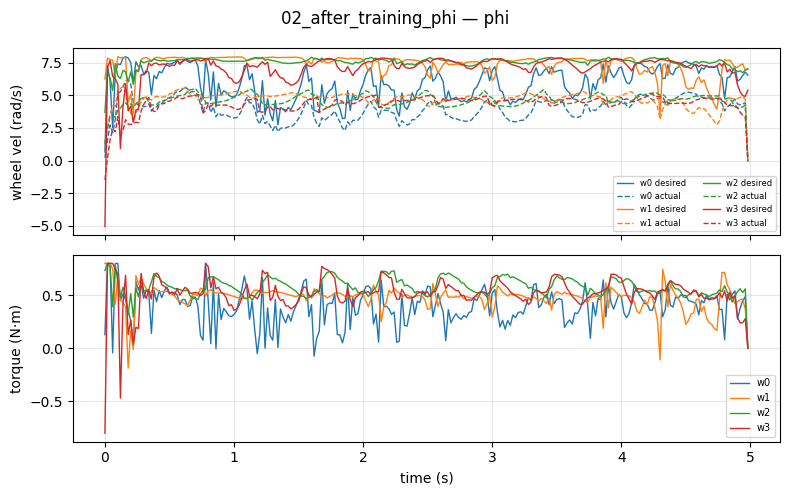

  avg_dist & std over 50 randomized episodes: 0.696 ± 0.021 m


In [11]:
print("Rendering AFTER training (deployed condition: ẑ from φ)...")
_ = render_phi_rollout(phi_params, label="02_after_training_phi", latent_mode="phi", plots=True)

# Single-trial max_x above is from the un-randomized render env. The line below
# averages over N_EVAL_EPISODES randomized rollouts → realistic test-time perf.
mean, std, _ = eval_avg_distance(phi_params, latent_mode="phi")
print(f"  avg_dist & std over {N_EVAL_EPISODES} randomized episodes: {mean:.3f} ± {std:.3f} m")

## Four-condition comparison

Same seed, same env init, only the latent fed to π changes. Shows how much of the teacher's behavior φ recovers (`phi` vs `mu`) and proves the gain isn't trivial (`zero`, `random` baselines).

First call per mode incurs a ~5–10 s jit compile.

In [12]:
for mode, label in [
    ("phi",    "03_compare_phi"),
    ("mu",     "03_compare_mu_teacher"),
    ("zero",   "03_compare_zero"),
    ("random", "03_compare_random"),
    ("ppo",    "03_compare_ppo"),
]:
    print(f"\n--- {mode} ---")
    _ = render_phi_rollout(phi_params, label=label, latent_mode=mode, seed=42)
    mean, std, _ = eval_avg_distance(phi_params, latent_mode=mode)
    print(f"  avg_dist & std over {N_EVAL_EPISODES} randomized episodes: {mean:.3f} ± {std:.3f} m")



--- phi ---


This browser does not support the video tag.


  [03_compare_phi] mode=phi max_x=0.69m  (11.4s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/03_compare_phi.mp4
  avg_dist & std over 50 randomized episodes: 0.696 ± 0.022 m

--- mu ---


This browser does not support the video tag.


  [03_compare_mu_teacher] mode=mu max_x=0.70m  (16.4s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/03_compare_mu_teacher.mp4
  avg_dist & std over 50 randomized episodes: 0.698 ± 0.027 m

--- zero ---


...

  [03_compare_zero] mode=zero max_x=0.66m  (16.1s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/03_compare_zero.mp4
  avg_dist & std over 50 randomized episodes: 0.649 ± 0.067 m

--- random ---


This browser does not support the video tag.


  [03_compare_random] mode=random max_x=0.69m  (16.9s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/03_compare_random.mp4
  avg_dist & std over 50 randomized episodes: 0.652 ± 0.031 m

--- ppo ---


This browser does not support the video tag.


  [03_compare_ppo] mode=ppo max_x=0.70m  (16.5s)  → logs/TWMRLegTerr-20260528-160033/phase2_videos/03_compare_ppo.mp4
  avg_dist & std over 50 randomized episodes: 0.676 ± 0.094 m


## Save trained φ

Saved next to the Phase 1 checkpoint. `test_phase2.py` will pick this file up automatically the next time it runs (it auto-finds the latest run dir).

saved φ to logs/TWMRLegTerr-20260528-160033/checkpoints/phi_final


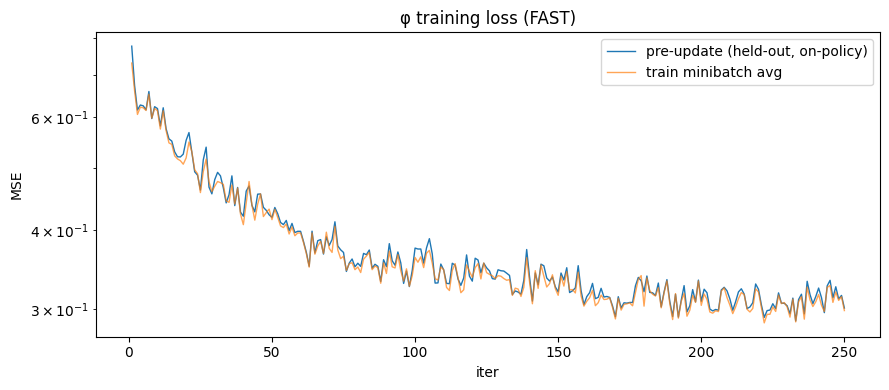


All outputs in logs/TWMRLegTerr-20260528-160033/phase2_videos


In [13]:
phi_save_path = CKPT_DIR / "phi_final"
model.save_params(str(phi_save_path), phi_params)
print(f"saved φ to {phi_save_path}")

# Loss curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(log["iter"], log["pre_loss"],   label="pre-update (held-out, on-policy)", lw=1)
ax.plot(log["iter"], log["train_loss"], label="train minibatch avg", lw=1, alpha=0.7)
ax.set_yscale("log"); ax.set_xlabel("iter"); ax.set_ylabel("MSE")
ax.legend(); ax.set_title(f"φ training loss ({PRESET})")
fig.tight_layout()
fig.savefig(VIDEO_DIR / "loss_curve.png", dpi=120)
plt.show()
print(f"\nAll outputs in {VIDEO_DIR}")
